In [1]:
import pandas as pd
import numpy as np

data = pd.read_csv('adolescent#001.csv')
data = data.drop(columns=["CGM", "CHO", "insulin", "LBGI", "Risk", "HBGI", "Time"])


glucose_levels = pd.read_csv("datatest_sim1.csv")
glucose_levels = glucose_levels.drop(columns=["CHO", "INS"])

data = data[:288] #2 недели
data.describe()


,BG
count,288.000000
mean,126.767131
std,24.580338
min,84.916006
25%,103.061359
50%,140.412940
75%,149.026852
max,161.588319


In [2]:
glucose_levels = data

288
[  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179
 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197
 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215
 216 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233
 234 235 236 237 238 239 240 241 242 243 244 24

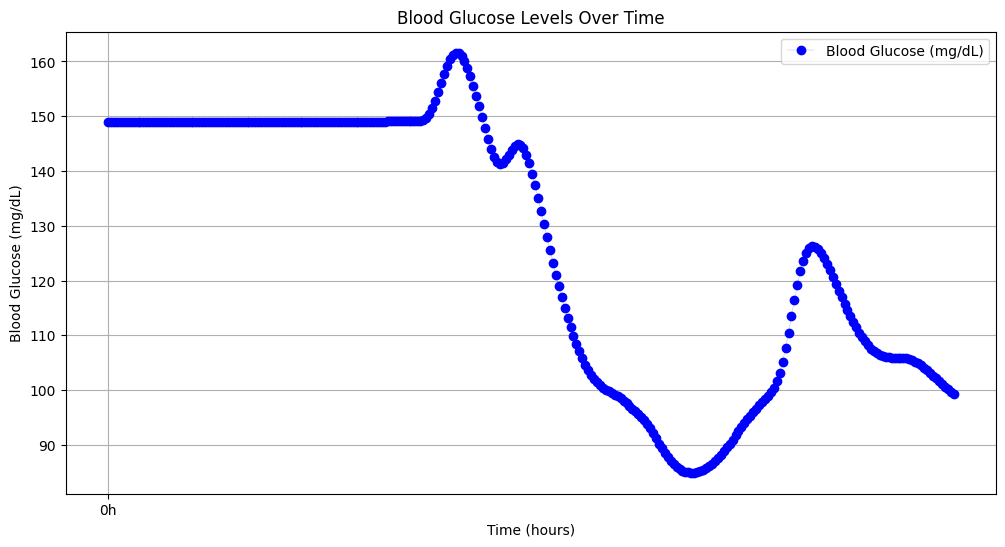

In [3]:
import matplotlib.pyplot as plt
import numpy as np


# Время - массив временных точек с шагом 3 минуты
num_points = len(glucose_levels) 
print(num_points)
# Время - массив временных точек с шагом 1 минута
time_points = np.arange(0, num_points)  # 720 точек, каждая по одной минуте
print(time_points)
# Построение диаграммы
plt.figure(figsize=(12, 6))
plt.plot(time_points, glucose_levels, marker='o', linestyle='-', color='b', label='Blood Glucose (mg/dL)', linewidth=0.1)
plt.title('Blood Glucose Levels Over Time')
plt.xlabel('Time (hours)')
plt.ylabel('Blood Glucose (mg/dL)')
plt.grid(True)

# Форматирование оси X, чтобы отображать каждый час
time_labels = [f'{int(t // 12)}h' for t in np.arange(0, num_points, 800)]  # Метки времени в часах
plt.xticks(np.arange(0, num_points, 800), time_labels)  # Шаг времени на оси X (каждый час)

plt.legend()
plt.show()





In [4]:
len(glucose_levels)

288

In [5]:
glucose_control_series = pd.Series(glucose_levels.squeeze(), index=range(len(glucose_levels)))

In [6]:
glucose_control_series.shape

(288,)

In [7]:
glucose_control = pd.DataFrame(glucose_control_series.values, columns=['cur_glucose_levels'])

In [8]:
glucose_control

,cur_glucose_levels
0,149.020000
1,149.020000
2,149.020000
3,149.020000
4,149.020000
...,...
283,101.109519
284,100.617746
285,100.148129
286,99.706615


In [9]:
#Лаги
for i in range(1, 6):  
    glucose_control[f'glucose_levels_lag_{i}'] = glucose_control_series.shift(i)

# Среднее между lag1 и lagi, пропуская NaN значения
for i in range(2, 5):
    glucose_control[f'glucose_mean_levels_lag_1_{i}'] = glucose_control[
        [f'glucose_levels_lag_1', f'glucose_levels_lag_{i}']
    ].mean(axis=1, skipna=True)

#Скользящее среднее
for window in [2, 3, 5, 10]:
    glucose_control[f'rolling_mean_{window}'] = glucose_control['cur_glucose_levels'].rolling(window=window).mean()


#Скользящее стандартное. Слабо влияет

for window in [1, 2, 3, 5, 10]:
    glucose_control[f'rolling_std_{window}'] = glucose_control['cur_glucose_levels'].rolling(window=window).std()


#Скользящее максимальное и минимальное значения
for window in [2, 3, 5, 10]:
    glucose_control[f'rolling_max_{window}'] = glucose_control['cur_glucose_levels'].rolling(window=window).max()
    glucose_control[f'rolling_min_{window}'] = glucose_control['cur_glucose_levels'].rolling(window=window).min()
    
    
#Дифференсы
for i in [1, 4]:
    glucose_control[f'diff_{i}'] = glucose_control['cur_glucose_levels'] - glucose_control['cur_glucose_levels'].shift(i)



#---Датасет не доработан, пока влияния на время суток нет
# Рассчитаем количество минут с начала суток для каждого значения
glucose_control['minute_of_day'] = (glucose_control.index % (24 * 60)) * 5

# Признак для часа в пределах суток и его циклические представления
glucose_control['hour_of_day'] = (glucose_control['minute_of_day'] // 60) % 24
glucose_control['hour_sin'] = np.sin(2 * np.pi * glucose_control['hour_of_day'] / 24)
glucose_control['hour_cos'] = np.cos(2 * np.pi * glucose_control['hour_of_day'] / 24)

# Признак для периода суток
glucose_control['day_period'] = glucose_control['hour_of_day'].apply(lambda x: 'night' if x < 6 else
                                                                     'morning' if x < 12 else
                                                                     'afternoon' if x < 18 else
                                                                     'evening')

# Признак для дня недели
glucose_control['day_of_week'] = ((glucose_control.index * 5) // (24 * 60)) % 7

# Преобразование категориальных признаков в числовые с использованием one-hot encoding
glucose_control = pd.get_dummies(glucose_control, columns=['day_period', 'day_of_week'])




In [10]:
glucose_control

,cur_glucose_levels,glucose_levels_lag_1,glucose_levels_lag_2,glucose_levels_lag_3,glucose_levels_lag_4,glucose_levels_lag_5,glucose_mean_levels_lag_1_2,glucose_mean_levels_lag_1_3,glucose_mean_levels_lag_1_4,rolling_mean_2,...,diff_4,minute_of_day,hour_of_day,hour_sin,hour_cos,day_period_afternoon,day_period_evening,day_period_morning,day_period_night,day_of_week_0
0,149.020000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0,0,0.000000,1.000000,False,False,False,True,True
1,149.020000,149.020000,NaN,NaN,NaN,NaN,149.020000,149.020000,149.020000,149.020000,...,NaN,5,0,0.000000,1.000000,False,False,False,True,True
2,149.020000,149.020000,149.020000,NaN,NaN,NaN,149.020000,149.020000,149.020000,149.020000,...,NaN,10,0,0.000000,1.000000,False,False,False,True,True
3,149.020000,149.020000,149.020000,149.020000,NaN,NaN,149.020000,149.020000,149.020000,149.020000,...,NaN,15,0,0.000000,1.000000,False,False,False,True,True
4,149.020000,149.020000,149.020000,149.020000,149.020000,NaN,149.020000,149.020000,149.020000,149.020000,...,2.744773e-07,20,0,0.000000,1.000000,False,False,False,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
283,101.109519,101.616638,102.131458,102.645586,103.150015,103.635336,101.874048,102.131112,102.383326,101.363079,...,-2.040495e+00,1415,23,-0.258819,0.965926,False,True,False,False,True
284,100.617746,101.109519,101.616638,102.131458,102.645586,103.150015,101.363079,101.620489,101.877553,100.863633,...,-2.027840e+00,1420,23,-0.258819,0.965926,False,True,False,False,True
285,100.148129,100.617746,101.109519,101.616638,102.131458,102.645586,100.863633,101.117192,101.374602,100.382938,...,-1.983329e+00,1425,23,-0.258819,0.965926,False,True,False,False,True
286,99.706615,100.148129,100.617746,101.109519,101.616638,102.131458,100.382938,100.628824,100.882384,99.927372,...,-1.910022e+00,1430,23,-0.258819,0.965926,False,True,False,False,True


In [11]:
X = glucose_control.drop('cur_glucose_levels', axis=1)
y = glucose_control['cur_glucose_levels']

In [12]:
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [14]:
model = CatBoostRegressor(loss_function='RMSE', iterations=100, learning_rate=0.1, depth=6)
model.fit(X_train, y_train, eval_set=(X_test, y_test), verbose=False)

In [15]:
predictions = model.predict(X_test)
mse = mean_squared_error(y_test, predictions)
print("Predictions:", predictions)
print("MSE:", mse)

Predictions: [148.65965478 111.86155045 110.43795155 148.71000963  94.04461988
 149.08703852 148.65026425  99.91278244 149.06914522  85.90058903
  97.10165904 149.13325533 158.62448515 103.06224049 148.4825317
  94.25988689 148.91381045  99.1602903  124.7812275  149.01526978
 106.54954035 148.9941341  154.60108209 100.53290036 149.09569945
 115.61657164 144.64850669 131.9813815  153.01203815 149.16462762
 148.33157829  92.30421556 115.84103598 121.62066056  94.01056834
 100.82993422 111.40885592 140.35226115  85.83124545 159.71777202
 103.083889   111.0304418  113.83520431 142.02241758 149.27831173
 148.19964215 148.73286928 111.94691772 135.95508185 101.4371394
 121.30512706 112.51334647 149.3065032   87.83810453  99.70775525
  95.25228976 103.47959183 148.91381045]
MSE: 1.1887203248322387


In [16]:
feature_importances = model.get_feature_importance()

In [17]:
feature_names = X_train.columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False).reset_index(drop=True)
print(importance_df)

print(importance_df['Importance'].sum())

                        Feature  Importance
0          glucose_levels_lag_2   16.199643
1   glucose_mean_levels_lag_1_4   15.241799
2   glucose_mean_levels_lag_1_2    8.646456
3                rolling_mean_2    8.558479
4                 minute_of_day    5.101586
5                   hour_of_day    4.988893
6                 rolling_min_5    4.017263
7                rolling_max_10    3.815528
8               rolling_mean_10    3.164519
9                 rolling_std_2    3.086388
10               rolling_mean_3    2.830669
11                     hour_sin    2.622096
12                rolling_min_3    2.603696
13                rolling_std_5    2.406316
14                rolling_std_3    2.263665
15  glucose_mean_levels_lag_1_3    1.868316
16               rolling_mean_5    1.711037
17                     hour_cos    1.561373
18                rolling_min_2    1.361105
19                rolling_max_5    1.336382
20               rolling_min_10    0.907249
21                rolling_max_3 

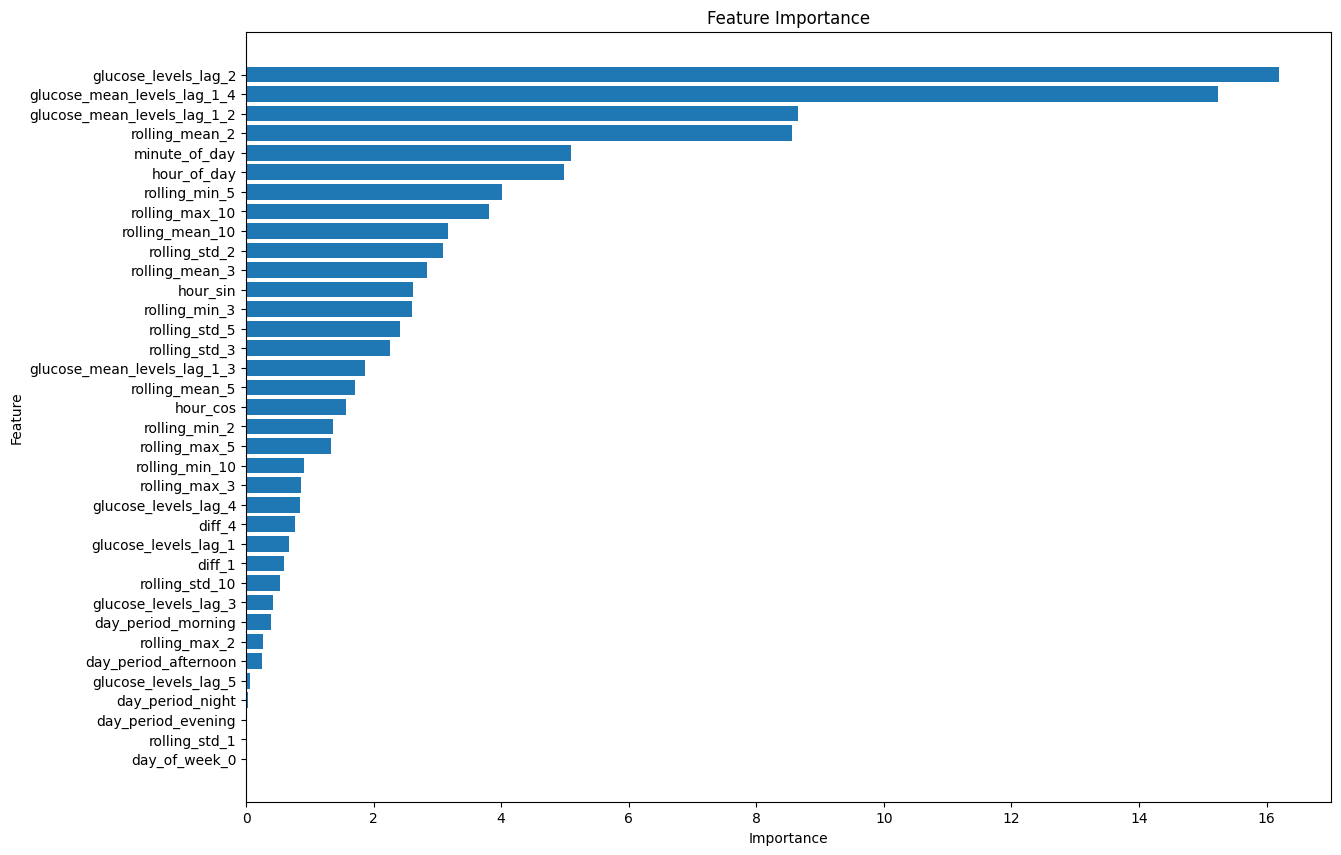

In [18]:
import matplotlib.pyplot as plt

# Визуализация значимости признаков
plt.figure(figsize=(14, 10))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance')
plt.gca().invert_yaxis()  
plt.show()

                        Feature  Importance_mean  Importance_std
5   glucose_mean_levels_lag_1_2        18.359772        2.684568
1          glucose_levels_lag_2        15.967792        2.423900
8                rolling_mean_2        12.511095        2.294492
7   glucose_mean_levels_lag_1_4         9.499701        1.518653
22                rolling_min_5         9.426962        1.543574
27                minute_of_day         7.431800        1.329929
29                     hour_sin         7.245388        1.356825
28                  hour_of_day         6.287702        0.718233
20                rolling_min_3         5.051294        1.037958
2          glucose_levels_lag_3         3.930733        0.664421
10               rolling_mean_5         3.826049        0.801988
24               rolling_min_10         3.682411        0.948024
0          glucose_levels_lag_1         3.602129        0.802951
9                rolling_mean_3         3.050260        0.615516
14                rolling

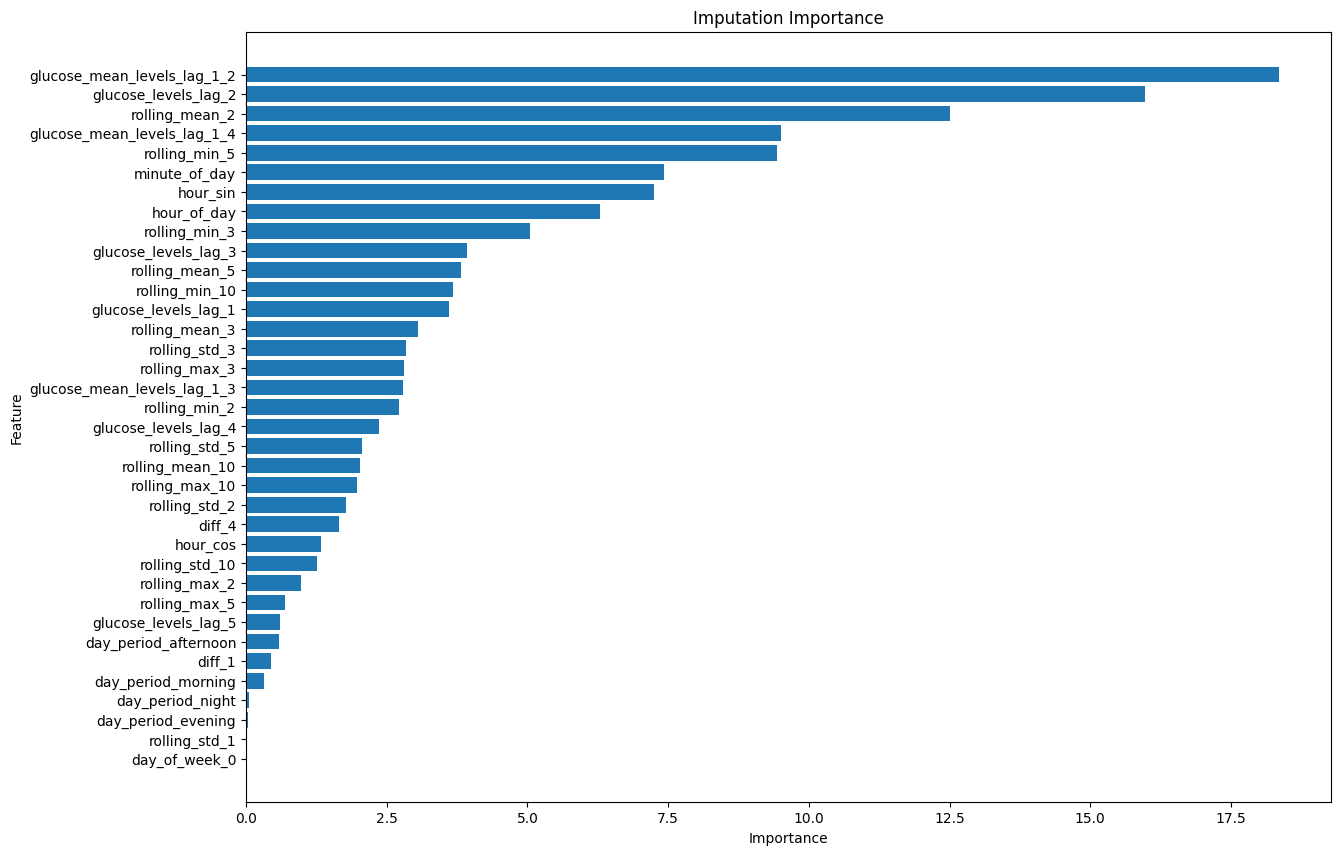

In [19]:
#PERMUTATION IMPORTANCE

from sklearn.inspection import permutation_importance
# Расчет Permutation Importance
result = permutation_importance(model, X_test, y_test, n_repeats=10, scoring='neg_mean_squared_error', random_state=42)

feature_importances = pd.DataFrame({
    'Feature': X_test.columns, 
    'Importance_mean': result.importances_mean,
    'Importance_std': result.importances_std
}).sort_values(by='Importance_mean', ascending=False)

print(feature_importances)

plt.figure(figsize=(14, 10))
plt.barh(feature_importances['Feature'], feature_importances['Importance_mean'])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Imputation Importance')
plt.gca().invert_yaxis()  
plt.show()


In [20]:
import numpy as np
import pandas as pd
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.inspection import permutation_importance


def addFeatures(glucose_control_series, glucose_control):
    # Лаги
    for i in range(1, 6):  
        glucose_control[f'glucose_levels_lag_{i}'] = glucose_control_series.shift(i)
        
    # Среднее между lag1 и lagi, пропуская NaN значения
    for i in range(2, 5):
        glucose_control[f'glucose_mean_levels_lag_1_{i}'] = glucose_control[
            [f'glucose_levels_lag_1', f'glucose_levels_lag_{i}']
        ].mean(axis=1, skipna=True)

    # Скользящее среднее
    for window in [2, 3, 5, 10]:
        glucose_control[f'rolling_mean_{window}'] = glucose_control['cur_glucose_levels'].rolling(window=window).mean()

    # Скользящее стандартное
    for window in [2, 3, 5, 10]:
        glucose_control[f'rolling_std_{window}'] = glucose_control['cur_glucose_levels'].rolling(window=window).std()

    # Скользящее максимальное и минимальное значения
    for window in [2, 3, 5, 10]:
        glucose_control[f'rolling_max_{window}'] = glucose_control['cur_glucose_levels'].rolling(window=window).max()
        glucose_control[f'rolling_min_{window}'] = glucose_control['cur_glucose_levels'].rolling(window=window).min()
        
    # Дифференсы
    for i in [1, 4]:
        glucose_control[f'diff_{i}'] = glucose_control['cur_glucose_levels'] - glucose_control['cur_glucose_levels'].shift(i)


    '''
    # Рассчитаем количество минут с начала суток для каждого значения
    glucose_control['minute_of_day'] = (glucose_control.index % (24 * 60)) * 5

    # Признак для часа в пределах суток и его циклические представления
    glucose_control['hour_of_day'] = (glucose_control['minute_of_day'] // 60) % 24
    glucose_control['hour_sin'] = np.sin(2 * np.pi * glucose_control['hour_of_day'] / 24)
    glucose_control['hour_cos'] = np.cos(2 * np.pi * glucose_control['hour_of_day'] / 24)

    # Признак для периода суток
    glucose_control['day_period'] = glucose_control['hour_of_day'].apply(lambda x: 'night' if x < 6 else
                                                                        'morning' if x < 12 else
                                                                        'afternoon' if x < 18 else
                                                                        'evening')

    # Признак для дня недели
    glucose_control['day_of_week'] = ((glucose_control.index * 5) // (24 * 60)) % 7

    # Преобразование категориальных признаков в числовые с использованием one-hot encoding
    glucose_control = pd.get_dummies(glucose_control, columns=['day_period', 'day_of_week'], drop_first=True)
    '''
    return glucose_control  # возвращаем результат



MSE: 0.09750204399167915
MSE: 1.3497388345973316
MSE: 0.536636785175096
MSE: 0.6530432888410224
MSE: 0.9242302178686219
MSE: 0.2367221375888631
MSE: 1.5318449336861932
MSE: 0.8535400453524771
MSE: 0.4681715660307579


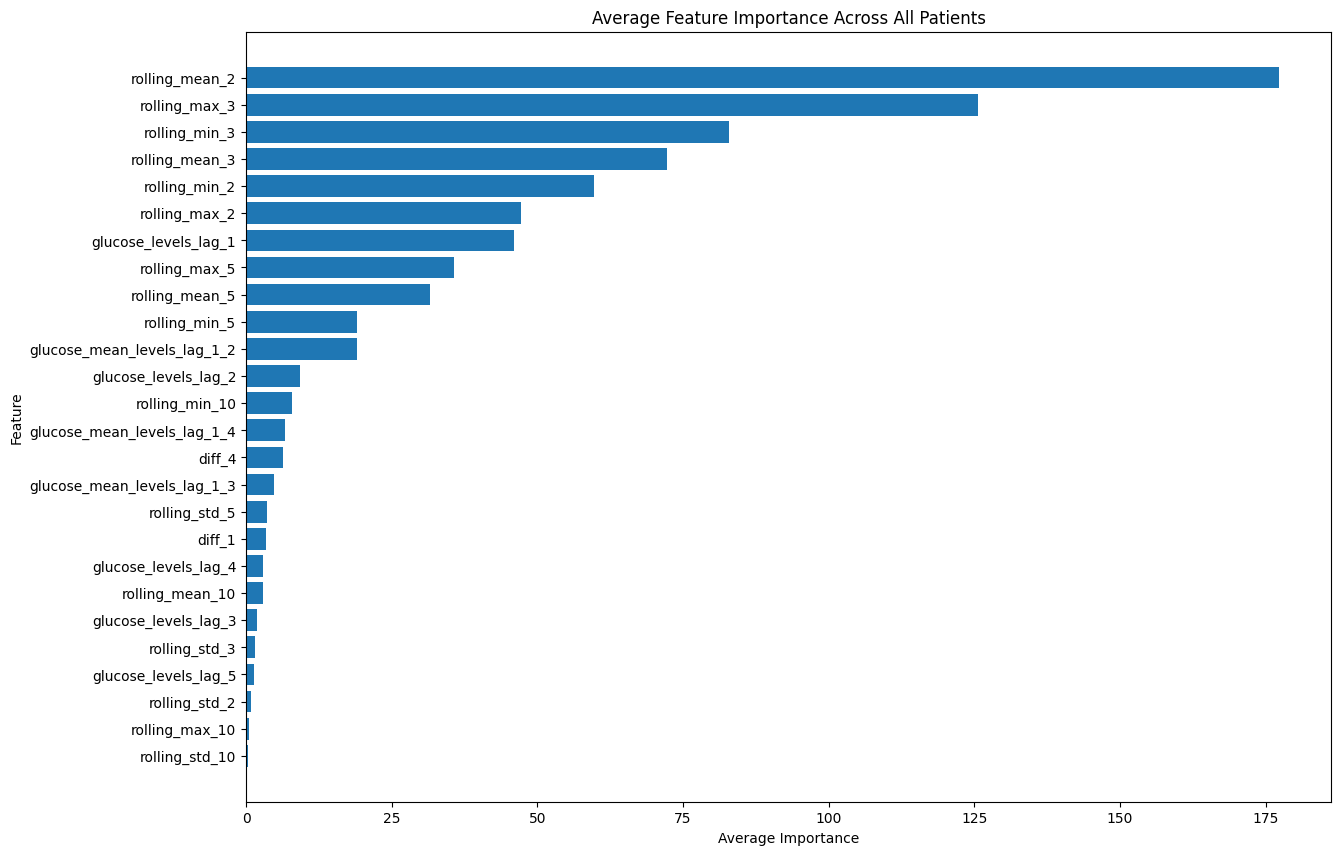

In [21]:
dataRes = []
for i in range(1, 10):
    # Чтение данных
    patient = pd.read_csv(f'adolescent#00{i}.csv')
    patient = patient[:4032]  # 2 недели
    patient = patient.drop(columns=["CGM", "CHO", "insulin", "LBGI", "Risk", "HBGI", "Time"])
    
    # Добавление фичей
    glucose_control_series = pd.Series(patient.squeeze(), index=range(len(patient)))
    glucose_control = pd.DataFrame(glucose_control_series.values, columns=['cur_glucose_levels'])
    glucose_control = addFeatures(glucose_control_series, glucose_control) 
    
    # Обучение
    X = glucose_control.drop('cur_glucose_levels', axis=1)
    y = glucose_control['cur_glucose_levels']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    model = CatBoostRegressor(loss_function='RMSE', iterations=250, learning_rate=0.1, depth=6)
    model.fit(X_train, y_train, eval_set=(X_test, y_test), verbose=False)
    
    # Тест
    predictions = model.predict(X_test)
    mse = mean_squared_error(y_test, predictions)
    print("MSE:", mse)
    
    
    # Расчет Permutation Importance
    result = permutation_importance(model, X_test, y_test, n_repeats=20, scoring='neg_mean_squared_error', random_state=42)
    
    # Создание FImportance dict
    importance_dict = {'Patient': f'Patient_{i}', 'MSE': mse}
    importance_dict.update({feature: importance for feature, importance in zip(X_test.columns, result.importances_mean)})
    
    dataRes.append(importance_dict)

# Преобразование dataRes в DataFrame для анализа
dataRes_df = pd.DataFrame(dataRes)
#print(dataRes_df)

# Вывод графика важности признаков для каждого пациента
for i in range(1, 1): #Не вывожу
    patient_importances = dataRes_df[dataRes_df['Patient'] == f'Patient_{i}']
    patient_importances = patient_importances.drop(columns=['Patient', 'MSE']).T
    patient_importances.columns = ['Importance_mean']
    
    # Сортируем по убыванию важности
    patient_importances = patient_importances.sort_values(by='Importance_mean', ascending=False)

    plt.figure(figsize=(14, 10))
    plt.barh(patient_importances.index, patient_importances['Importance_mean'])
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.title(f'Feature Importance for Patient_{i}')
    plt.gca().invert_yaxis()
    plt.show()
    
    
#Чекаем среднюю важность по признакам
average_importances = dataRes_df.drop(columns=['Patient', 'MSE']).mean().sort_values(ascending=False)

# Выводим среднее значение важности признаков
plt.figure(figsize=(14, 10))
plt.barh(average_importances.index, average_importances.values)
plt.xlabel('Average Importance')
plt.ylabel('Feature')
plt.title('Average Feature Importance Across All Patients')
plt.gca().invert_yaxis()
plt.show()


In [22]:
dataRes_df[dataRes_df['Patient'] == 'Patient_1']

,Patient,MSE,glucose_levels_lag_1,glucose_levels_lag_2,glucose_levels_lag_3,glucose_levels_lag_4,glucose_levels_lag_5,glucose_mean_levels_lag_1_2,glucose_mean_levels_lag_1_3,glucose_mean_levels_lag_1_4,...,rolling_max_2,rolling_min_2,rolling_max_3,rolling_min_3,rolling_max_5,rolling_min_5,rolling_max_10,rolling_min_10,diff_1,diff_4
0,Patient_1,0.097502,4.272547,1.092457,0.591554,0.372008,0.10706,5.054539,3.921154,1.689377,...,7.222528,8.237094,9.156588,8.830847,0.224441,3.772731,0.046889,0.512006,0.318842,1.097335


In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance
from catboost import CatBoostRegressor

# Функция для кластеризации признаков на основе порога корреляции
def threshold_clustering(X, threshold=0.9):
    corr_matrix = X.corr().abs()  # Вычисляем матрицу абсолютных значений корреляции
    clusters = []
    used_columns = set()  # Храним уже обработанные признаки

    for column in corr_matrix.columns:
        if column in used_columns:
            continue
        # Находим признаки с высокой корреляцией
        high_corr = corr_matrix[column][corr_matrix[column] > threshold].index.tolist()
        clusters.append(high_corr)
        used_columns.update(high_corr)
    
    # Преобразуем в формат словаря для удобства
    cluster_dict = {i: clusters[i] for i in range(len(clusters))}
    return cluster_dict

# Функция для вычисления кластерной Permutation Importance
def cluster_permutation_importance(model, X_test, y_test, clusters, n_repeats=10):
    baseline_score = mean_squared_error(y_test, model.predict(X_test))
    cluster_importance = {}

    for cluster, features in clusters.items():
        scores = []
        for _ in range(n_repeats):
            X_permuted = X_test.copy()
            for feature in features:
                X_permuted[feature] = np.random.permutation(X_permuted[feature])

            permuted_score = mean_squared_error(y_test, model.predict(X_permuted))
            scores.append(permuted_score)

        cluster_importance[f"Cluster_{cluster}"] = np.mean(scores) - baseline_score

    return cluster_importance

# Основной код
dataRes = []
for i in range(1, 10):
    # Чтение данных
    patient = pd.read_csv(f'adolescent#00{i}.csv')
    patient = patient[:4032]  # 2 недели
    patient = patient.drop(columns=["CGM", "CHO", "insulin", "LBGI", "Risk", "HBGI", "Time"])
    
    # Добавление фичей
    glucose_control_series = pd.Series(patient.squeeze(), index=range(len(patient)))
    glucose_control = pd.DataFrame(glucose_control_series.values, columns=['cur_glucose_levels'])
    glucose_control = addFeatures(glucose_control_series, glucose_control)  # применяем и получаем измененный DataFrame

    # Обучение
    X = glucose_control.drop('cur_glucose_levels', axis=1)
    y = glucose_control['cur_glucose_levels']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    model = CatBoostRegressor(loss_function='RMSE', iterations=250, learning_rate=0.1, depth=6)
    model.fit(X_train, y_train, eval_set=(X_test, y_test), verbose=False)
    
    # Тест
    predictions = model.predict(X_test)
    mse = mean_squared_error(y_test, predictions)
    print(f"Patient_{i} MSE:", mse)
    
    # Кластеризация признаков на основе порога корреляции
    clusters = threshold_clustering(X_test, threshold=0.9)
    
    # Вывод кластеров в более понятном формате
    print(f"Clusters for Patient_{i}:")
    for cluster_id, features in clusters.items():
        print(f"Cluster {cluster_id}: {features}")
    
    # Расчет кластерной Permutation Importance
    cluster_importance = cluster_permutation_importance(model, X_test, y_test, clusters)
    print(f"Cluster Importances for Patient_{i}:", cluster_importance)

    # Сохраняем результаты кластерной важности для текущего пациента
    importance_dict = {'Patient': f'Patient_{i}', 'MSE': mse}
    importance_dict.update(cluster_importance)
    dataRes.append(importance_dict)

# Преобразование dataRes в DataFrame для анализа
dataRes_df = pd.DataFrame(dataRes)
print(dataRes_df)




Patient_1 MSE: 0.09750204399167915
Clusters for Patient_1:
Cluster 0: ['glucose_levels_lag_1', 'glucose_levels_lag_2', 'glucose_levels_lag_3', 'glucose_levels_lag_4', 'glucose_levels_lag_5', 'glucose_mean_levels_lag_1_2', 'glucose_mean_levels_lag_1_3', 'glucose_mean_levels_lag_1_4', 'rolling_mean_2', 'rolling_mean_3', 'rolling_mean_5', 'rolling_mean_10', 'rolling_max_2', 'rolling_min_2', 'rolling_max_3', 'rolling_min_3', 'rolling_max_5', 'rolling_min_5', 'rolling_max_10', 'rolling_min_10']
Cluster 1: ['rolling_std_2', 'rolling_std_3', 'rolling_std_5']
Cluster 2: ['rolling_std_10']
Cluster 3: ['diff_1', 'diff_4']
Cluster Importances for Patient_1: {'Cluster_0': 322.03101531869936, 'Cluster_1': 0.21162043980242462, 'Cluster_2': 0.01789609837912469, 'Cluster_3': 1.962221375297546}
Patient_2 MSE: 1.3497388345973316
Clusters for Patient_2:
Cluster 0: ['glucose_levels_lag_1', 'glucose_levels_lag_2', 'glucose_levels_lag_3', 'glucose_levels_lag_4', 'glucose_levels_lag_5', 'glucose_mean_levels_

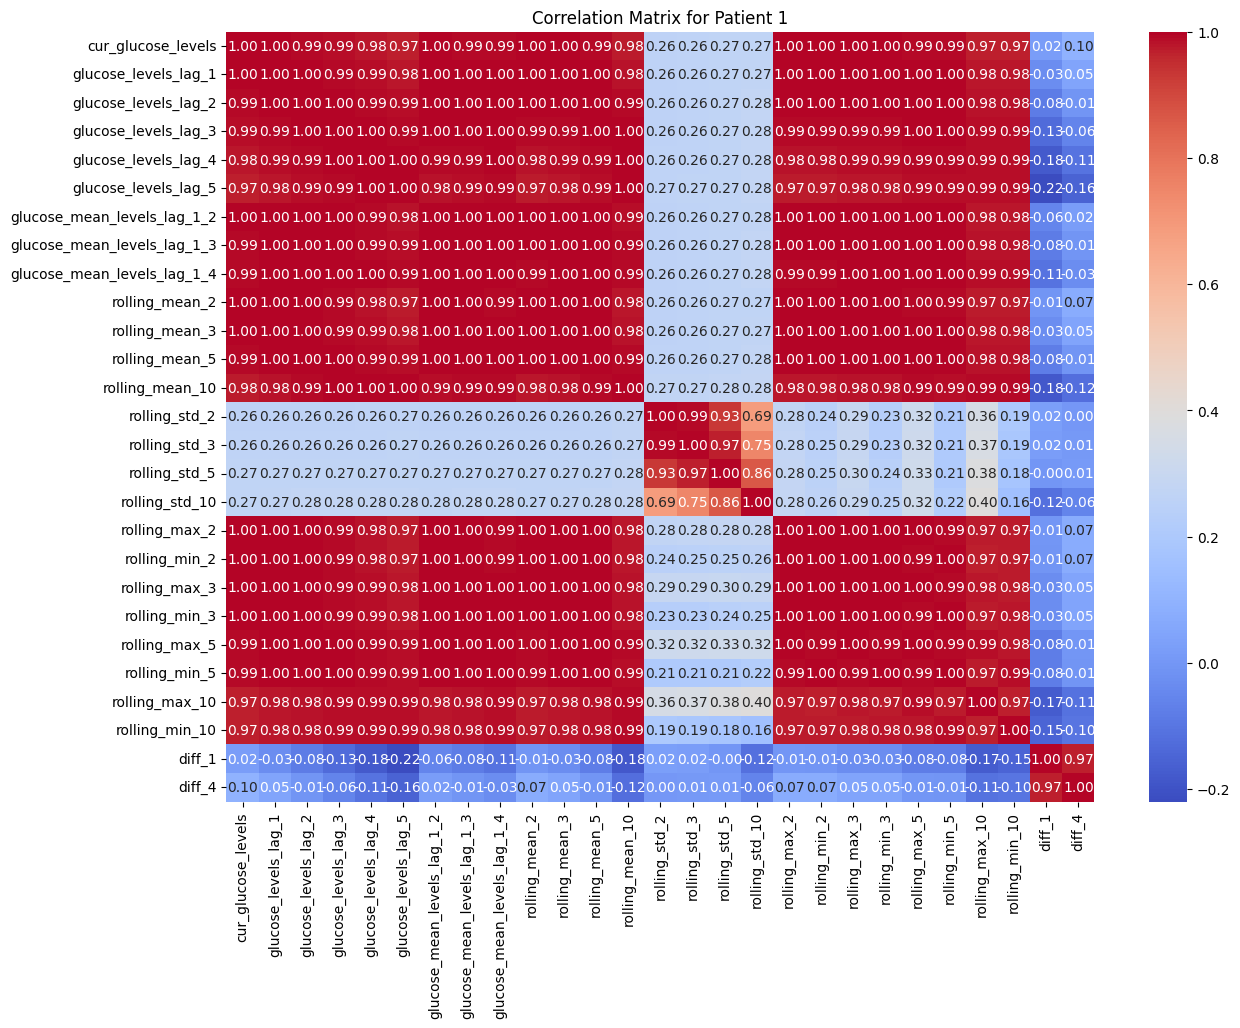

In [27]:
#Матрица корреляций для pat1

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Загрузка данных для Patient_1
patient1 = pd.read_csv('adolescent#001.csv')
patient1 = patient1[:4032]  # Ограничение на 2 недели
patient1 = patient1.drop(columns=["CGM", "CHO", "insulin", "LBGI", "Risk", "HBGI", "Time"])

glucose_control_series = pd.Series(patient1.squeeze(), index=range(len(patient1)))
glucose_control = pd.DataFrame(glucose_control_series.values, columns=['cur_glucose_levels'])

glucose_control = addFeatures(glucose_control_series, glucose_control)

# Вычисление матрицы корреляций для всех признаков
correlation_matrix = glucose_control.corr()

plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix for Patient 1")
plt.show()
